# Handwritten solving

## Displaying an Image in Jupyter

In this step, we import the `Image` function from `IPython.display`.  
This allows us to show images directly inside the notebook.  

We then display the file **`handwritten.png`**, which serves as a visual introduction to the task.  
It helps set the context by showing an example of handwritten digits that we will later classify using machine learning.

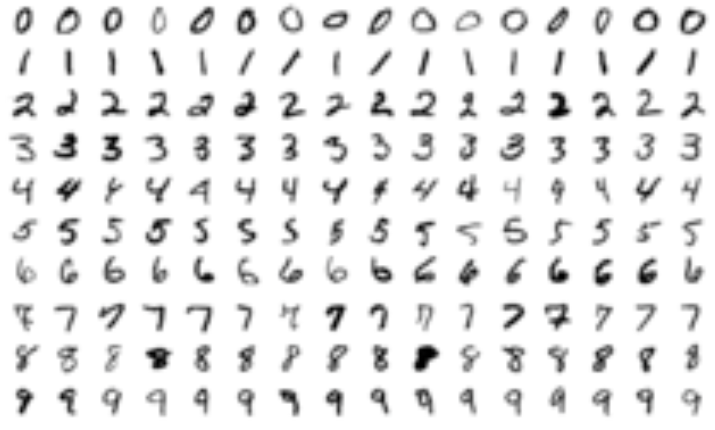

In [1]:
from IPython.display import Image
Image('handwritten.png',width = 600, height = 300)

## Loading essential libraries

In [2]:
import numpy as np   #numerical operations
import matplotlib.pyplot as plt #plotting

In [3]:
from tensorflow import keras 
from tensorflow.keras.datasets import mnist #mnist dataset = classic handwritten digits dataset
from tensorflow.keras.models import Sequential, load_model #sequential : model type where layers are stacked in order
from tensorflow.keras.layers import Dense, Dropout, Activation  #building blocks of neural networks
from tensorflow.keras.utils import to_categorical #converts labels into one-hot encoded format for classification

In [4]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()  #loads the MINST dataset \ 
                                                       #splits intro training (60,000 images) and test (10,000) \
                                                       #each image is 28 x 28 pixels

In [5]:
print('Dimension of X_train', X_train.shape) #X_train (60000, 28, 28) = 60k images each 28x28 pixels
print('Dimension of y_train', y_train.shape) #labels for training images
print('Dimension of X_test', X_test.shape)
print('Dimension of y_test', y_test.shape) #labels for test images

Dimension of X_train (60000, 28, 28)
Dimension of y_train (60000,)
Dimension of X_test (10000, 28, 28)
Dimension of y_test (10000,)


In [6]:
X_train[0] #diplays the pixel values of the first training image \
           #OUTPUT = 28x28 array of grayscale values (0-255)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
print(y_train[0]) #shows the label of the first training image

5


In [8]:
print(np.unique(y_train)) #print the unique values

[0 1 2 3 4 5 6 7 8 9]


## Displaying Multiple Training Images

In this step, we create a grid of 9 images from the training dataset:

- `fig = plt.figure()` → Creates a new figure to hold multiple plots.  
- **Loop (`for i in range(9)`)** → Iterates through the first 9 training images.  
- `plt.subplot(3,3,i+1)` → Arranges the images in a 3×3 grid.  
- `plt.tight_layout()` → Adjusts spacing so titles and images don’t overlap.  
- `plt.imshow(..., cmap='gray')` → Displays each image in grayscale.  
- `plt.title(...)` → Adds the digit label above each image.  
- `plt.xticks([]), plt.yticks([])` → Removes axis ticks for a cleaner look.  

This visualization helps us quickly inspect multiple samples and confirm that the labels match the images.

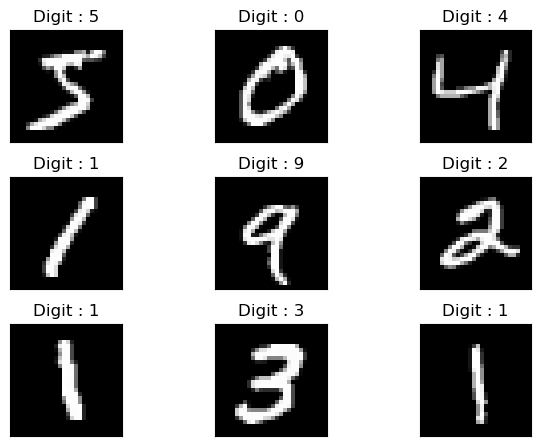

In [9]:
fig = plt.figure()
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(X_train[i],cmap = 'gray')
    plt.title('Digit : {}'.format(y_train[i]))
    plt.xticks([])
    plt.yticks([])

This cell combines two visualizations:

- `fig = plt.figure()` → Creates a new figure to hold multiple plots.  
- **First subplot (2,1,1)** → Displays the first training image in grayscale with its digit label.  
- **Second subplot (2,1,2)** → Plots a histogram of the pixel intensities for that image.  
- `reshape(784)` → Flattens the 28×28 image into a 784‑element vector so pixel values can be counted.  
- **Histogram** → Shows how many pixels fall into each intensity range (0–255).  

Together, these plots let us see both the digit itself and the distribution of its pixel values, which highlights why normalization is important before training a neural network.


Text(0.5, 1.0, 'Distribution of pixels values')

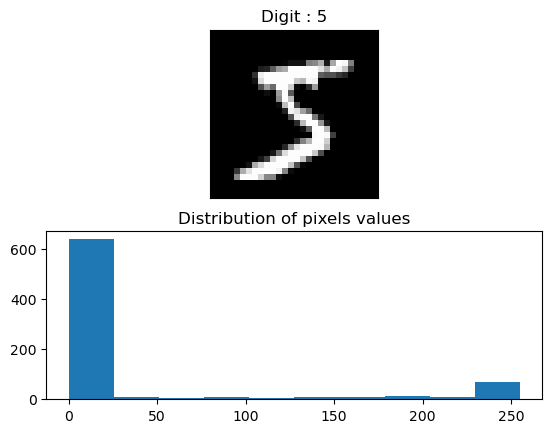

In [10]:
fig = plt.figure()
plt.subplot(2,1,1)
plt.imshow(X_train[0],cmap = 'gray')
plt.title('Digit : {}'.format(y_train[0]))
plt.xticks([])
plt.yticks([])
plt.subplot(2,1,2)
plt.hist(X_train[0].reshape(784))
plt.title('Distribution of pixels values')

## Reshaping and Converting Data Types

**Reshape:**
- `X_train.reshape(60000, 784)` → Flattens each 28×28 image into a 784‑element vector.  
- `X_test.reshape(10000, 784)` → Does the same for the test set.  
- This transformation prepares the data for input into a fully connected neural network.

**Type conversion:**
- `astype('float32')` → Converts pixel values from integers to 32‑bit floating point numbers.  
- Neural networks work more efficiently with floating‑point values during training.

In [11]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

## Normalizing Pixel Values

After reshaping and converting the data type, we normalize the pixel values:

- `X_train /= 255` → Divides every pixel value in the training set by 255.  
- `X_test /= 255` → Does the same for the test set.  

Since grayscale pixel intensities range from **0 to 255**, dividing by 255 scales them into the range **0–1**.  
This normalization step is crucial because:
- It ensures all features (pixels) are on the same scale.  
- It improves numerical stability during training.  
- It helps the neural network converge faster and more reliably.

In [12]:
X_train /= 255
X_test /= 255

## Preparing Labels for One‑Hot Encoding

- `nb_classes = 10` → Defines the number of output classes (digits 0–9).  
- `print('Dimension avant one-hot-encoder', y_train.shape)` → Prints the shape of the training labels before applying one‑hot encoding.  

This step is a **sanity check**: it shows that the labels are still in their original integer form (shape `(60000,)`).  
By confirming this, we can then proceed to transform them into one‑hot encoded vectors, which are required for classification tasks in Keras.


In [13]:
nb_classes = 10
print('Dimension before one-hot-encoder', y_train.shape)

Dimension before one-hot-encoder (60000,)


## One-Hot Encoding the Labels

- `Y_train = to_categorical(y_train, nb_classes)` → Converts the integer labels (digits 0–9) into one‑hot encoded vectors.  

For example:  
- Digit **5** becomes `[0,0,0,0,0,1,0,0,0,0]`.  
- Digit **0** becomes `[1,0,0,0,0,0,0,0,0,0]`.  

This transformation is essential because the neural network will output probabilities across **10 classes**.  
One‑hot encoding ensures that the labels are in the same format as the model’s output, making training possible.


In [14]:
Y_train = to_categorical(y_train,nb_classes)

In [15]:
print('Dimension after one-hot-encoder', Y_train.shape)

Dimension after one-hot-encoder (60000, 10)


In [16]:
print(y_train[0]) #check after one-hot

5


In [17]:
Y_train[0] #check after one hot

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## Building the Neural Network Model

**Sequential model** refers to a specific way of building neural networks in frameworks like Keras (part of TensorFlow). <br>
## What is a Sequential Model?
* A Sequential model is a linear stack of layers.
* You add one layer after another, and data flows strictly forward from the input layer through each hidden layer to the output layer.
* It’s the simplest way to build a neural network when your architecture is straightforward (no branching, no multiple inputs/outputs).

We define a feed‑forward neural network using Keras `Sequential`:

1. **Model initialization**
   - `model = Sequential()` → Creates a linear stack of layers.
   - `Sequential()` → Used because the network is a simple stack of layers where each layer feeds into the next.
   - Ideal for straightforward feed‑forward architectures like multi‑layer perceptrons (MLPs).

2. **First hidden layer**
   - `Dense(512, input_shape=(784,))` → Fully connected layer with 512 neurons, input size 784 (flattened image).
   - `Activation('relu')` → Applies ReLU activation for non‑linearity.
   - `Dropout(0.2)` → Randomly drops 20% of neurons during training to reduce overfitting.

   - **Large number** of neurons allows the model to **learn complex patterns** in the data.
   - 512 is a common choice that **balances expressive power with computational efficiency**.
   - `relu` (Rectified Linear Unit) → Introduces non‑linearity, enabling the network to learn complex relationships.
   ==> Efficient to compute and helps mitigate the vanishing gradient problem compared to sigmoid/tanh.
   - `Dropout(0.2)` → Randomly disables 20% of neurons during training.
   ==> Prevents overfitting by forcing the network to learn more robust features instead of memorizing.

3. **Second hidden layer**
   - `Dense(512)` → Another fully connected layer with 512 neurons.
   - `Activation('relu')` → Again uses ReLU activation.
   - `Dropout(0.2)` → Adds dropout for regularization.

>>> Multiple layers allow the network to learn hierarchical representations:
     - First layer captures lower‑level features (edges, shapes).
     - Second layer combines them into higher‑level abstractions (digit structures).

4. **Output layer**
   - `Dense(10)` → Final layer with 10 neurons (one per digit class).
   - Each neuron corresponds to one digit class (0–9).
   - Ensures the output dimension matches the number of categories in the dataset.
   - `Activation('softmax')` → Converts outputs into probability distribution across the 10 classes.
   - Converts raw scores into probabilities that sum to 1.
   - Makes interpretation straightforward: the highest probability indicates the predicted digit.

This architecture is a **multi‑layer perceptron (MLP)** with two large hidden layers, ReLU activations, dropout for regularization, and a softmax output for classification.


In [18]:
model = Sequential()

model.add(Dense(512, input_shape=(784,)))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(10))
model.add(Activation('softmax'))

C:\Users\abidc\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compiling the Model

After defining the architecture, we compile the model to specify how it will learn:

- **Loss function**
  - `loss='categorical_crossentropy'`  
  → Used for multi‑class classification problems.  
  → Measures the difference between predicted probability distribution and the true one‑hot encoded labels.

- **Metrics**
  - `metrics=['accuracy']`  
  → Tracks the proportion of correctly classified digits during training and evaluation.  
  → Provides an intuitive measure of performance.

- **Optimizer**
  - `optimizer='adam'`  
  → Adaptive Moment Estimation (Adam) is a popular optimizer that combines the benefits of RMSProp and momentum.  
  → Efficient, requires little tuning, and works well for most deep learning tasks.

---

**Summary:**  
Compiling the model defines the **objective (loss)**, the **performance measure (accuracy)**, and the **optimization strategy (Adam)**. This prepares the network for training on the MNIST dataset.


In [19]:
model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'], optimizer = 'adam')

## One‑Hot Encoding Test Labels

- `Y_test = to_categorical(y_test, nb_classes)`  
  → Converts the integer test labels (digits 0–9) into one‑hot encoded vectors, just like we did for the training labels.

**Why this step matters:**
- Ensures consistency: both training (`Y_train`) and test (`Y_test`) labels are in the same format.  
- The model outputs a probability distribution across 10 classes, so the labels must also be represented as 10‑dimensional vectors.  
- Without encoding `y_test`, evaluation would fail because predictions (vectors) wouldn’t match the labels (integers).

✅ Example:  
- Digit **7** becomes `[0,0,0,0,0,0,0,1,0,0]`.  
- Digit **2** becomes `[0,0,1,0,0,0,0,0,0,0]`.


In [20]:
Y_test = to_categorical(y_test,nb_classes)

## Training the Model

We now train the neural network using `model.fit`:

- **Training data**
  - `X_train, Y_train` → Inputs (flattened images) and labels (one‑hot encoded digits).

- **Batch size**
  - `batch_size=128` → The model processes 128 samples at a time before updating weights.
  - Larger batch sizes speed up training but may reduce generalization.

- **Epochs**
  - `epochs=20` → The model will iterate over the entire training dataset 20 times.
  - More epochs allow deeper learning, but too many can cause overfitting.

- **Verbose**
  - `verbose=2` → Displays training progress in a concise format (one line per epoch).

- **Validation data**
  - `validation_data=(X_test, Y_test)` → Evaluates performance on unseen test data after each epoch.
  - Helps monitor overfitting and generalization during training.

---

**Summary:**  
This step actually **teaches the model** to classify handwritten digits by repeatedly adjusting weights to minimize the loss function, while tracking accuracy on both training and validation sets.


In [21]:
history = model.fit(X_train,Y_train,
                   batch_size = 128,
                   epochs = 20,
                   verbose = 2,
                   validation_data = (X_test,Y_test))

Epoch 1/20
469/469 - 12s - 26ms/step - accuracy: 0.9243 - loss: 0.2511 - val_accuracy: 0.9599 - val_loss: 0.1258
Epoch 2/20
469/469 - 9s - 18ms/step - accuracy: 0.9692 - loss: 0.0982 - val_accuracy: 0.9789 - val_loss: 0.0730
Epoch 3/20
469/469 - 8s - 17ms/step - accuracy: 0.9775 - loss: 0.0708 - val_accuracy: 0.9782 - val_loss: 0.0678
Epoch 4/20
469/469 - 8s - 18ms/step - accuracy: 0.9817 - loss: 0.0555 - val_accuracy: 0.9753 - val_loss: 0.0815
Epoch 5/20
469/469 - 8s - 17ms/step - accuracy: 0.9853 - loss: 0.0447 - val_accuracy: 0.9803 - val_loss: 0.0635
Epoch 6/20
469/469 - 9s - 19ms/step - accuracy: 0.9871 - loss: 0.0380 - val_accuracy: 0.9805 - val_loss: 0.0705
Epoch 7/20
469/469 - 8s - 17ms/step - accuracy: 0.9888 - loss: 0.0346 - val_accuracy: 0.9789 - val_loss: 0.0666
Epoch 8/20
469/469 - 8s - 18ms/step - accuracy: 0.9903 - loss: 0.0300 - val_accuracy: 0.9818 - val_loss: 0.0626
Epoch 9/20
469/469 - 8s - 17ms/step - accuracy: 0.9916 - loss: 0.0250 - val_accuracy: 0.9819 - val_loss

## Model Summary

- `model.summary()` → Displays a detailed overview of the network architecture.  
- It shows:
  - **Layer types** (Dense, Activation, Dropout).  
  - **Output shapes** → the dimensions of data flowing through each layer.  
  - **Number of parameters** → trainable weights and biases for each layer.  
  - **Total parameters** → sum of all trainable and non‑trainable parameters in the model.

**Why it’s useful:**
- Provides a quick check to confirm the model is built as intended.  
- Helps ensure input/output dimensions match expectations.  
- Allows you to see how many parameters the network will train, which indicates model complexity and computational cost.


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,009,120 (7.66 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,339,414 (5.11 MB)

## Model Visualization

We plot the training and validation accuracy across epochs to see how the model learns:

- `plt.plot(history.history['accuracy'])`  
  → Plots the accuracy on the training set for each epoch.

- `plt.plot(history.history['val_accuracy'])`  
  → Plots the accuracy on the validation (test) set for each epoch.

- `plt.title('Model Accuracy')`  
  → Adds a title to the plot.

- `plt.xlabel('Epoch')` and `plt.ylabel('Accuracy')`  
  → Label the x‑axis (epochs) and y‑axis (accuracy).

- `plt.legend(['Train','Test'])`  
  → Adds a legend to distinguish between training and validation curves.

---

✅ **Summary:**  
This visualization helps you evaluate whether the model is improving over time, and whether it generalizes well.  
- If training accuracy rises but validation accuracy stagnates or drops, it indicates **overfitting**.  
- If both curves rise steadily and stay close, the model is learning effectively.


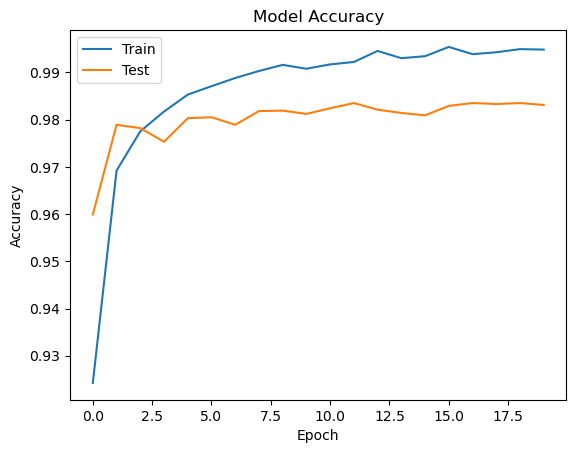

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Test'])

We plot the training and validation loss across epochs to understand how well the model is learning:

- `plt.plot(history.history['loss'])`  
  → Plots the loss on the training set for each epoch.

- `plt.plot(history.history['val_loss'])`  
  → Plots the loss on the validation (test) set for each epoch.

- `plt.title('Model Loss')`  
  → Adds a title to the plot.

- `plt.xlabel('Epoch')` and `plt.ylabel('Loss')`  
  → Label the x‑axis (epochs) and y‑axis (loss).

- `plt.legend(['Train','Test'])`  
  → Adds a legend to distinguish between training and validation curves.

---

✅ **Summary:**  
This visualization shows how the model’s error decreases over time.  
- If both training and validation loss decrease steadily, the model is learning effectively.  
- If training loss decreases but validation loss stagnates or increases, it indicates **overfitting**.  
- Ideally, both curves should follow similar trends, staying close together.


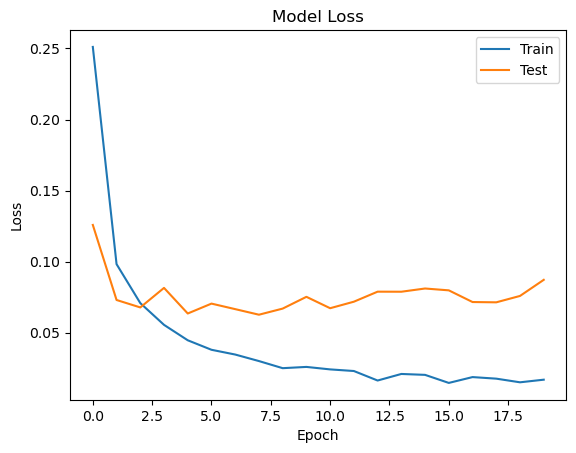

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Test'])

## Save the Model

**What is an `.h5` file?**

An `.h5` file is a file format based on **HDF5 (Hierarchical Data Format version 5)**.  
It’s widely used in scientific computing and machine learning because it can store large, complex datasets in a structured way.

When you save a Keras model as `.h5`, here’s what it contains:

- **Model architecture** → the structure of the layers (Sequential, Dense, Dropout, etc.).  
- **Weights** → the learned parameters from training.  
- **Optimizer state** → information about the optimizer (like Adam) so training can resume seamlessly.  
- **Training configuration** → loss function, metrics, and optimizer settings.

In [25]:
# Save the entire model (architecture + weights + optimizer state)
model.save('my_model.h5')

## Evaluating Model Performance

Why .h5 is useful ???
It’s a single portable file that you can share or move between systems.

You can reload the model later with:

In [26]:
mnist_model = load_model('my_model.h5')

We use `model.evaluate` to measure the model’s performance on unseen test data:

- **Command**
  ```python
  loss_and_metrics = mnist_model.evaluate(X_test, Y_test, verbose=2)
  print('Loss test', loss_and_metrics[0])
  print('Accuracy test', loss_and_metrics[1])


In [27]:
loss_and_metrics = mnist_model.evaluate(X_test,Y_test,verbose = 2)
print('Loss test', loss_and_metrics[0])
print('Accuracy test', loss_and_metrics[1])

313/313 - 3s - 8ms/step - accuracy: 0.9831 - loss: 0.0872
Loss test 0.08718148618936539
Accuracy test 0.9830999970436096


## Making Predictions on Test Data

We use the trained model to predict the digit classes for the test set:

- **Command**
  ```python
  predict_x = mnist_model.predict(X_test)
  predicted_classes = np.argmax(predict_x, axis=1)


In [28]:
predict_x=mnist_model.predict(X_test) 
predicted_classes=np.argmax(predict_x,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [29]:
for i in range(10):
    print(y_test[i],predicted_classes[i])

7 7
2 2
1 1
0 0
4 4
1 1
4 4
9 9
5 5
9 9


In [30]:
np.nonzero(predicted_classes!=y_test) #identifying misclassifiec samples

(array([ 115,  151,  247,  321,  340,  445,  495,  582,  619,  659,  674,
         691,  720,  844,  877,  895,  900,  947,  951,  956, 1014, 1112,
        1156, 1226, 1242, 1247, 1289, 1299, 1319, 1328, 1331, 1393, 1395,
        1414, 1522, 1530, 1549, 1553, 1584, 1681, 1717, 1754, 1790, 1878,
        1901, 1941, 2004, 2024, 2035, 2053, 2093, 2109, 2125, 2130, 2135,
        2182, 2293, 2329, 2369, 2387, 2488, 2597, 2654, 2743, 2810, 2877,
        2921, 2927, 2938, 2939, 2995, 3073, 3117, 3172, 3289, 3336, 3405,
        3422, 3475, 3503, 3520, 3558, 3565, 3597, 3702, 3727, 3767, 3778,
        3796, 3808, 3853, 3902, 3906, 3941, 3985, 4052, 4065, 4140, 4176,
        4199, 4201, 4248, 4255, 4271, 4289, 4294, 4306, 4360, 4374, 4382,
        4497, 4639, 4761, 4763, 4807, 4823, 4860, 5331, 5457, 5634, 5642,
        5676, 5734, 5918, 5936, 5937, 5955, 5972, 5973, 5982, 5997, 6023,
        6028, 6555, 6571, 6576, 6597, 6625, 6651, 6755, 6783, 7216, 7451,
        7800, 7821, 8062, 8094, 8255, 

In [31]:
print(y_test[151],predicted_classes[151])

9 8


In [32]:
#separating correct and incorrect predictions
correct_indices = np.nonzero(predicted_classes == y_test)[0]
incorrect_indices = np.nonzero(predicted_classes!=y_test)[0]

In [33]:
print(len(correct_indices), 'digits correctly classified')
print(len(incorrect_indices), 'digits incorrectly classified')

9831 digits correctly classified
169 digits incorrectly classified


**Visualizing Correctly Classified Digits**

We plot a few examples of test images that the model classified correctly:

```python

- `plt.rcParams['figure.figsize'] = (10,15)` → Sets the overall figure size.  

- `enumerate(correct_indices[:9])` → Loops through the first 9 correctly classified samples.  

- `plt.subplot(6,3,i+1)` → Creates a grid of subplots to display multiple images.  

- `plt.imshow(...)` → Displays the digit image in grayscale.  

- `plt.title(...)` → Shows both the predicted label and the true label for each digit.  

- `plt.xticks([]), plt.yticks([])` → Removes axis ticks for cleaner visualization.

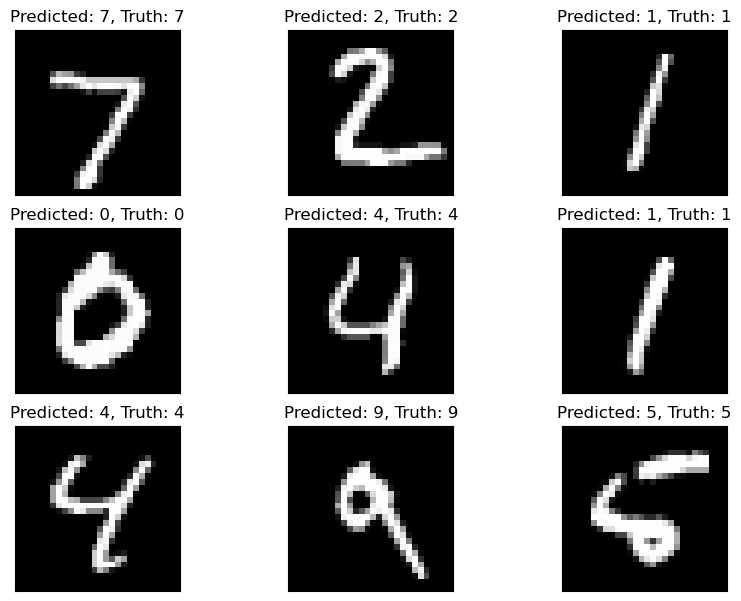

In [34]:
plt.rcParams['figure.figsize'] = (10,15)

for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(6,3,i+1)
    plt.imshow(X_test[correct].reshape(28,28),cmap='gray')
    plt.title('Predicted: {}, Truth: {}'.format(predicted_classes[correct],y_test[correct]))
    plt.xticks([])
    plt.yticks([])

**Visualizing Incorrectly Classified Digits**

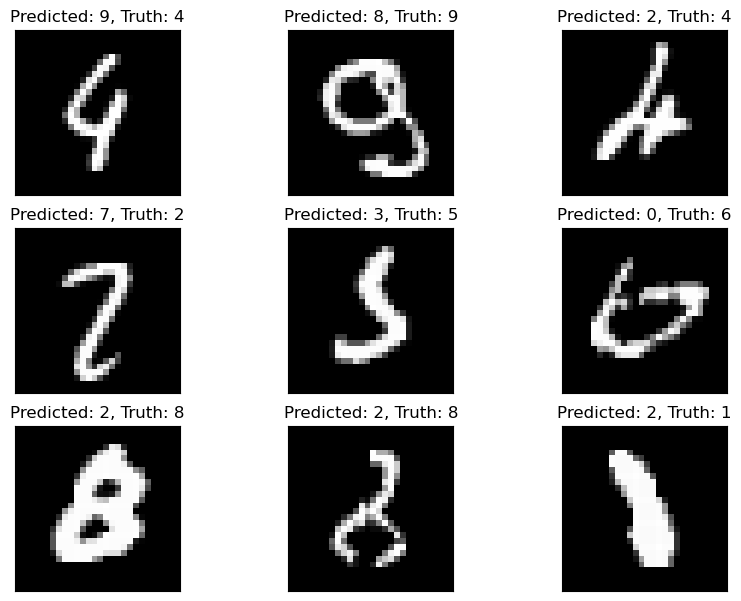

In [35]:
plt.rcParams['figure.figsize'] = (10,15)

for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(6,3,i+1)
    plt.imshow(X_test[incorrect].reshape(28,28),cmap='gray')
    plt.title('Predicted: {}, Truth: {}'.format(predicted_classes[incorrect],y_test[incorrect]))
    plt.xticks([])
    plt.yticks([])